# Tutorial: CryptoHFTData Workflow

Using [cryptohftdata.com](https://www.cryptohftdata.com/) which has free historical orderbook data. This notebook shows the full workflow for downloading historical orderbook and trades data from CryptoHFTData, converting it into HftBacktest's normalized `.npz` format, deriving an end-of-day snapshot, and running a simple backtest.

The notebook is saved with executed outputs so you can inspect the entire workflow without rerunning it.


## What This Notebook Does

1. Download the full `2026-03-01` and `2026-03-02` CryptoHFTData datasets for `binance_futures / BTCUSDT`.
2. Convert both full-day datasets with `hftbacktest.data.utils.cryptohftdata`.
3. Reconstruct the end-of-day snapshot from day 1.
4. Replay day 2 through a small market-making loop.
5. Record PnL/equity state and render the standard HftBacktest summary and chart.


In [ ]:
import gc
import io
import os
import time
from contextlib import redirect_stderr, redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from numba import njit

from hftbacktest import BacktestAsset, GTX, HashMapMarketDepthBacktest, LIMIT, Recorder
from hftbacktest.data.utils import cryptohftdata
from hftbacktest.data.utils.snapshot import create_last_snapshot
from hftbacktest.stats import LinearAssetRecord

API_KEY = "YOUR API KEY FROM CRYPTOPHFTDATA"

# We use Binance Futures BTCUSDT as the canonical example for the integration.
EXCHANGE = "binance_futures"
SYMBOL = "BTCUSDT"
DAY1 = "2026-03-01"
DAY2 = "2026-03-02"
MAX_WORKERS = 10

# All generated data stays under a notebook-local temp directory.
WORKDIR = Path("tmp/cryptohftdata_workflow")
WORKDIR.mkdir(parents=True, exist_ok=True)

DAY1_FILE = WORKDIR / "btcusdt_20260301.npz"
DAY2_FILE = WORKDIR / "btcusdt_20260302.npz"
DAY1_EOD_SNAPSHOT = WORKDIR / "btcusdt_20260301_eod.npz"

# We collect output artifact metadata as we go so the notebook ends with a concise inventory.
artifact_rows = []

print("Exchange:", EXCHANGE)
print("Symbol:", SYMBOL)
print("Days:", DAY1, "and", DAY2)
print("Temporary working directory:", WORKDIR)


Exchange: binance_futures
Symbol: BTCUSDT
Days: 2026-03-01 and 2026-03-02
Temporary working directory: tmp/cryptohftdata_workflow


In [2]:
def download_full_day(day: str):
    """Download one full day of orderbook + trades through the official CryptoHFTData SDK.

    The SDK uses tqdm internally for hourly chunk downloads. We redirect that noisy output and replace it with
    a short summary so the executed notebook remains readable.
    """
    stdout_buffer = io.StringIO()
    stderr_buffer = io.StringIO()
    started = time.perf_counter()

    with redirect_stdout(stdout_buffer), redirect_stderr(stderr_buffer):
        orderbook, trades = cryptohftdata.download(
            symbol=SYMBOL,
            exchange=EXCHANGE,
            start_date=day,
            end_date=day,
            api_key=API_KEY,
            max_workers=MAX_WORKERS,
        )

    elapsed = time.perf_counter() - started
    return orderbook, trades, elapsed


def prepare_day(day: str, output_file: Path):
    """Download, inspect, convert, and save a full day of CryptoHFTData data."""
    print(f"Downloading full-day orderbook + trades data for {day}...")
    orderbook, trades, elapsed = download_full_day(day)

    print(f"Download finished in {elapsed:.1f} seconds")
    print(f"Orderbook rows: {len(orderbook):,}")
    print(f"Trades rows:    {len(trades):,}")
    print("Orderbook columns:", list(orderbook.columns))
    print("Trades columns:", list(trades.columns))
    print()
    print(f"{day} orderbook preview")
    display(orderbook.head(5))
    print(f"{day} trades preview")
    display(trades.head(5))

    # The converter accepts the SDK's pandas DataFrames directly and writes the normalized HftBacktest array.
    started = time.perf_counter()
    data = cryptohftdata.convert(
        orderbook=orderbook,
        trades=trades,
        output_filename=str(output_file),
    )
    convert_elapsed = time.perf_counter() - started

    print(f"Converted rows: {len(data):,}")
    print(f"Conversion finished in {convert_elapsed:.1f} seconds")
    print("First local timestamp:", int(data[0]["local_ts"]))
    print("Last local timestamp:", int(data[-1]["local_ts"]))
    print("Saved file:", output_file)
    print("Saved file size (MB):", round(output_file.stat().st_size / 1024 / 1024, 2))

    artifact_rows.append(
        {
            "file": str(output_file),
            "rows": len(data),
            "size_mb": round(output_file.stat().st_size / 1024 / 1024, 2),
        }
    )

    # Explicit cleanup matters here because the full-day DataFrames are large.
    del orderbook, trades, data
    gc.collect()


## Download and Convert Day 1


In [3]:
prepare_day(DAY1, DAY1_FILE)


Download finished in 29.0 seconds
Orderbook rows: 137,715,336
Trades rows:    5,849,908
Orderbook columns: ['received_time', 'event_time', 'transaction_time', 'symbol', 'event_type', 'first_update_id', 'final_update_id', 'prev_final_update_id', 'last_update_id', 'side', 'price', 'quantity', 'order_count']
Trades columns: ['received_time', 'event_time', 'symbol', 'trade_id', 'price', 'quantity', 'trade_time', 'is_buyer_maker', 'order_type']

2026-03-01 orderbook preview


,received_time,event_time,transaction_time,symbol,event_type,first_update_id,final_update_id,prev_final_update_id,last_update_id,side,price,quantity,order_count
0,1772323200015532906,1772323199897,1772323199896,BTCUSDT,update,10009695044277,10009695046996,10009695043779,NaN,ask,66937.10,8.751,NaN
1,1772323200015532906,1772323199897,1772323199896,BTCUSDT,update,10009695044277,10009695046996,10009695043779,NaN,ask,66950.00,26.384,NaN
2,1772323200015532906,1772323199897,1772323199896,BTCUSDT,update,10009695044277,10009695046996,10009695043779,NaN,ask,66952.10,0.000,NaN
3,1772323200015532906,1772323199897,1772323199896,BTCUSDT,update,10009695044277,10009695046996,10009695043779,NaN,ask,66952.90,0.239,NaN
4,1772323200015532906,1772323199897,1772323199896,BTCUSDT,update,10009695044277,10009695046996,10009695043779,NaN,ask,66954.80,0.807,NaN


2026-03-01 trades preview


,received_time,event_time,symbol,trade_id,price,quantity,trade_time,is_buyer_maker,order_type
0,1772323200015929068,1772323199896,BTCUSDT,7357055064,66937.00,0.014,1772323199896,True,MARKET
1,1772323200020078316,1772323199901,BTCUSDT,7357055065,66937.00,0.036,1772323199901,True,MARKET
2,1772323200021264985,1772323199902,BTCUSDT,7357055066,66937.00,0.005,1772323199901,True,MARKET
3,1772323200021303683,1772323199902,BTCUSDT,7357055067,66937.00,0.036,1772323199901,True,MARKET
4,1772323200111132383,1772323199992,BTCUSDT,7357055068,66937.10,0.002,1772323199992,False,MARKET


Correcting the latency


Correcting the event order


Saving to tmp/cryptohftdata_workflow/btcusdt_20260301.npz


Converted rows: 146,085,261
Conversion finished in 160.4 seconds
First local timestamp: 1772323200015532906
Last local timestamp: 1772409599981351431
Saved file: tmp/cryptohftdata_workflow/btcusdt_20260301.npz
Saved file size (MB): 1000.35


## Download and Convert Day 2


In [4]:
prepare_day(DAY2, DAY2_FILE)


Download finished in 29.1 seconds
Orderbook rows: 184,633,539
Trades rows:    7,573,981
Orderbook columns: ['received_time', 'event_time', 'transaction_time', 'symbol', 'event_type', 'first_update_id', 'final_update_id', 'prev_final_update_id', 'last_update_id', 'side', 'price', 'quantity', 'order_count']
Trades columns: ['received_time', 'event_time', 'symbol', 'trade_id', 'price', 'quantity', 'trade_time', 'is_buyer_maker', 'order_type']

2026-03-02 orderbook preview


,received_time,event_time,transaction_time,symbol,event_type,first_update_id,final_update_id,prev_final_update_id,last_update_id,side,price,quantity,order_count
0,1772409600013578422,1772409599884,1772409599880,BTCUSDT,update,10016735091447,10016735094780,10016735091438,NaN,ask,65750.00,1.598,NaN
1,1772409600013578422,1772409599884,1772409599880,BTCUSDT,update,10016735091447,10016735094780,10016735091438,NaN,ask,65751.50,0.004,NaN
2,1772409600013578422,1772409599884,1772409599880,BTCUSDT,update,10016735091447,10016735094780,10016735091438,NaN,ask,65755.10,0.000,NaN
3,1772409600013578422,1772409599884,1772409599880,BTCUSDT,update,10016735091447,10016735094780,10016735091438,NaN,ask,65756.40,0.000,NaN
4,1772409600013578422,1772409599884,1772409599880,BTCUSDT,update,10016735091447,10016735094780,10016735091438,NaN,ask,65756.50,0.006,NaN


2026-03-02 trades preview


,received_time,event_time,symbol,trade_id,price,quantity,trade_time,is_buyer_maker,order_type
0,1772409600190018582,1772409600060,BTCUSDT,7363021426,65749.90,0.050,1772409600060,True,MARKET
1,1772409600199743589,1772409600070,BTCUSDT,7363021427,65750.00,0.019,1772409600070,False,MARKET
2,1772409600220935526,1772409600091,BTCUSDT,7363021428,65749.90,0.100,1772409600091,True,MARKET
3,1772409600222706925,1772409600093,BTCUSDT,7363021429,65749.90,0.219,1772409600093,True,MARKET
4,1772409600716426786,1772409600587,BTCUSDT,7363021430,0,0,1772409600587,True,NA


Correcting the latency
Correcting the event order


Saving to tmp/cryptohftdata_workflow/btcusdt_20260302.npz


Converted rows: 195,932,021
Conversion finished in 220.8 seconds
First local timestamp: 1772409600013578422
Last local timestamp: 1772495999954654610
Saved file: tmp/cryptohftdata_workflow/btcusdt_20260302.npz
Saved file size (MB): 1328.31


## Build the Day 1 End-of-Day Snapshot

CryptoHFTData's orderbook feed is update-based, so the initial snapshot for day 2 is reconstructed by replaying the converted day 1 data through HftBacktest's book builder.


In [5]:
snapshot = create_last_snapshot(
    [str(DAY1_FILE)],
    tick_size=0.1,
    lot_size=0.001,
    output_snapshot_filename=str(DAY1_EOD_SNAPSHOT),
)

print("Snapshot rows:", len(snapshot))
print("Snapshot file:", DAY1_EOD_SNAPSHOT)
print("Snapshot file size (MB):", round(DAY1_EOD_SNAPSHOT.stat().st_size / 1024 / 1024, 2))
display(pd.DataFrame(snapshot[:10]))

artifact_rows.append(
    {
        "file": str(DAY1_EOD_SNAPSHOT),
        "rows": len(snapshot),
        "size_mb": round(DAY1_EOD_SNAPSHOT.stat().st_size / 1024 / 1024, 2),
    }
)


Snapshot rows: 49568
Snapshot file: tmp/cryptohftdata_workflow/btcusdt_20260301_eod.npz
Snapshot file size (MB): 0.26


,ev,exch_ts,local_ts,px,qty,order_id,ival,fval
0,3758096388,0,0,65749.9,7.521,0,0,0.0
1,3758096388,0,0,65749.8,0.251,0,0,0.0
2,3758096388,0,0,65749.7,0.033,0,0,0.0
3,3758096388,0,0,65749.2,0.001,0,0,0.0
4,3758096388,0,0,65749.0,0.001,0,0,0.0
5,3758096388,0,0,65748.8,0.004,0,0,0.0
6,3758096388,0,0,65748.7,0.001,0,0,0.0
7,3758096388,0,0,65748.4,0.004,0,0,0.0
8,3758096388,0,0,65748.2,0.003,0,0,0.0
9,3758096388,0,0,65748.1,0.001,0,0,0.0


## Define a Small Market-Making Loop

The goal here is not to optimize a strategy. The loop below is intentionally simple and only exists to demonstrate that the converted CryptoHFTData feed can drive a normal HftBacktest run while we record equity/PnL data for charts.


In [6]:
@njit
def demo_market_maker(hbt, recorder):
    asset_no = 0
    tick_size = hbt.depth(asset_no).tick_size
    lot_size = hbt.depth(asset_no).lot_size
    order_qty = max(lot_size, np.round(0.002 / lot_size) * lot_size)

    next_order_id = 0
    record_interval = 60_000_000_000  # 60 seconds in nanoseconds
    next_record_ts = 0

    while True:
        # Advance the replay clock in small steps so the strategy can react to the stream.
        status = hbt.elapse(50_000_000)
        if status != 0:
            recorder.record(hbt)
            return status

        # Record state periodically for summary statistics and the equity/PnL chart.
        if hbt.current_timestamp >= next_record_ts:
            recorder.record(hbt)
            next_record_ts = hbt.current_timestamp + record_interval

        hbt.clear_inactive_orders(asset_no)

        depth = hbt.depth(asset_no)
        best_bid = depth.best_bid_tick * tick_size
        best_ask = depth.best_ask_tick * tick_size

        # Cancel currently cancellable orders so we can refresh both sides of the quote.
        orders = hbt.orders(asset_no)
        values = orders.values()
        while values.has_next():
            order = values.get()
            if order.cancellable:
                hbt.cancel(asset_no, order.order_id, False)

        # Give the cancellation requests a short amount of simulated time to progress.
        if hbt.elapse(50_000_000) != 0:
            recorder.record(hbt)
            return 1

        # Quote the current top of book with one order on each side.
        bid_order_id = next_order_id
        hbt.submit_buy_order(asset_no, bid_order_id, best_bid, order_qty, GTX, LIMIT, False)
        next_order_id += 1

        ask_order_id = next_order_id
        hbt.submit_sell_order(asset_no, ask_order_id, best_ask, order_qty, GTX, LIMIT, False)
        next_order_id += 1

        # Let the market advance before the next refresh cycle.
        if hbt.elapse(500_000_000) != 0:
            recorder.record(hbt)
            return 1


## Run the Backtest on Day 2 and Record Performance


In [7]:
# The asset configuration matches the converted CryptoHFTData feed format and the reconstructed day 1 snapshot.
asset = (
    BacktestAsset()
        .data([str(DAY2_FILE)])
        .initial_snapshot(str(DAY1_EOD_SNAPSHOT))
        .linear_asset(1.0)
        .constant_order_latency(10_000_000, 10_000_000)
        .risk_adverse_queue_model()
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.1)
        .lot_size(0.001)
)

hbt = HashMapMarketDepthBacktest([asset])
recorder = Recorder(1, 50_000)

loop_status = demo_market_maker(hbt, recorder.recorder)
records = recorder.get(0)

print("Loop status:", loop_status)
print("Recorded rows:", len(records))
print("Final timestamp:", hbt.current_timestamp)
print("Final position:", hbt.position(0))
print("Best bid / ask:", hbt.depth(0).best_bid, hbt.depth(0).best_ask)

_ = hbt.close()

# Resample the recorded equity series to make the summary and chart easier to read.
stats = LinearAssetRecord(records).resample('5m').stats(book_size=10_000)


Loop status: 1
Recorded rows: 1442
Final timestamp: 1772495999930000000
Final position: 3.7619999999998073
Best bid / ask: 68801.7 68801.8


## Backtest Summary


In [8]:
stats.summary()


start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 23:55:00,2026-03-02 23:55:00,9.530357,14.971662,0.262851,0.274995,46371.0,625.402049,0.955837,0.00042,260386.3108


## PnL / Equity Chart

This uses HftBacktest's standard `stats.plot()` output, the same style used across the existing example notebooks.


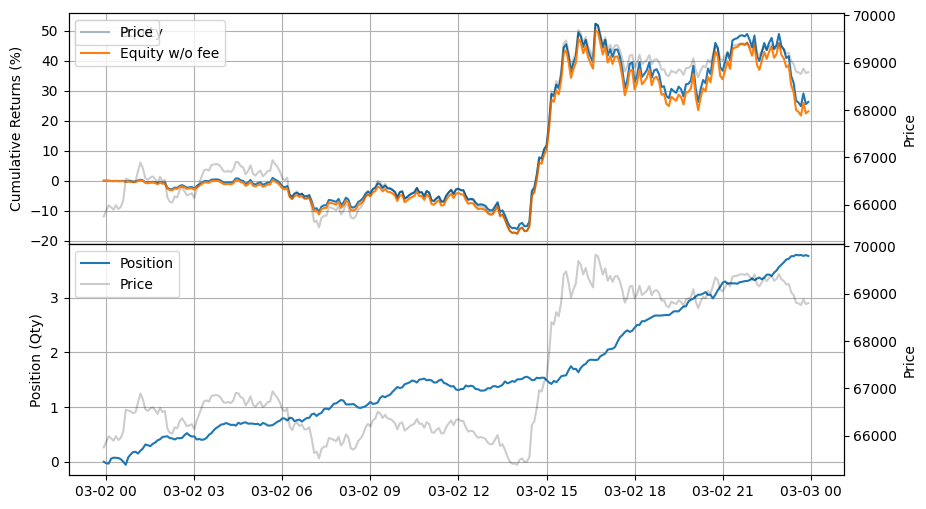

In [9]:
stats.plot()


## Artifacts Produced by This Run


In [10]:
display(pd.DataFrame(artifact_rows))


,file,rows,size_mb
0,tmp/cryptohftdata_workflow/btcusdt_20260301.npz,146085261,1000.35
1,tmp/cryptohftdata_workflow/btcusdt_20260302.npz,195932021,1328.31
2,tmp/cryptohftdata_workflow/btcusdt_20260301_eo...,49568,0.26
